<a href="https://colab.research.google.com/github/Ansh-One8/Machine-Learning-models-and-algos/blob/main/spamhamProject_using_word2vec_%2C_avgword2vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 33.9 MB/s eta 0:00:00


In [2]:
import gensim
from gensim.models import Word2Vec, keyedvectors
import gensim.downloader as api
wv = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [38]:
eg = wv['king']
len(eg) # so it has 300 dimension

300

In [27]:
import kagglehub
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.utils import simple_preprocess

# Download NLTK resources required for preprocessing
nltk.download('stopwords')
nltk.download('wordnet')

# The previous LookupError for 'punkt_tab' occurred because 'nltk.sent_tokenize' was used.
# The revised preprocessing function below does not use 'sent_tokenize', so 'punkt_tab'
# is no longer required for this specific implementation.

# Download Kaggle dataset
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")
print("Path to dataset files:", path)

# Load and rename messages DataFrame
messages = pd.read_csv(f"{path}/spam.csv", encoding="latin-1")
messages = messages[['v1' , 'v2']]
messages = messages.rename(columns = {'v1':'labels', 'v2' : 'messages'})
messages = messages.reset_index(drop=True) # Reset index and drop the old one

# Initialize lemmatizer and stopwords set
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Define preprocessing function
def preprocess_text(text):
    # Tokenize using gensim's simple_preprocess
    tokenized_message = simple_preprocess(text)
    # Remove stopwords and lemmatize tokens
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokenized_message if word not in stop_words]
    return cleaned_tokens

# Apply preprocessing to the messages column and store in a new column
messages['processed_messages'] = messages['messages'].apply(preprocess_text)

# Optional: If you still need 'words' as a flattened list of all processed words
all_processed_words = [word for sublist in messages['processed_messages'] for word in sublist]

# Optional: If 'review' was intended to be the list of lists of processed words
review = messages['processed_messages'].tolist()

print("\nFirst 5 rows of messages DataFrame with processed text:")
print(messages.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset

First 5 rows of messages DataFrame with processed text:
  labels                                           messages  \
0    ham  Go until jurong point, crazy.. Available only ...   
1    ham                      Ok lar... Joking wif u oni...   
2   spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3    ham  U dun say so early hor... U c already then say...   
4    ham  Nah I don't think he goes to usf, he lives aro...   

                                  processed_messages  
0  [go, jurong, point, crazy, available, bugis, g...  
1                        [ok, lar, joking, wif, oni]  
2  [free, entry, wkly, comp, win, fa, cup, final,...  
3               [dun, say, early, hor, already, say]  
4        [nah, think, go, usf, life, around, though]  


In [11]:
import pandas as pd
import numpy as np
#transfrom the data as i just wanted the important data columns
messages = pd.read_csv(f"{path}/spam.csv", encoding="latin-1")
messages = messages[['v1' , 'v2']]
messages = messages.rename(columns = {'v1':' labels', 'v2' : 'messages'})


In [12]:
messages

,labels,messages
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


#should i first clean & transform this like remove stopwords and do lemmatization or do test train split first?

> Add blockquote



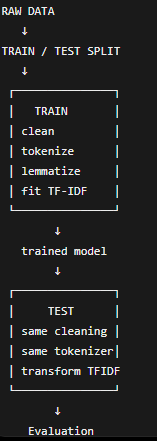

In [13]:
#from sklearn.model_selection import train_test_split
#x_train , x_test , y_train , y_test  = train_test_split(x , y ,random_state=23 , test_size=0.20 , )

NameError: name 'x' is not defined

In [29]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [16]:
messages = messages.reset_index()

In [42]:
len(messages)
messages

,labels,messages,processed_messages
0,ham,"Go until jurong point, crazy.. Available only ...","[go, jurong, point, crazy, available, bugis, g..."
1,ham,Ok lar... Joking wif u oni...,"[ok, lar, joking, wif, oni]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entry, wkly, comp, win, fa, cup, final,..."
3,ham,U dun say so early hor... U c already then say...,"[dun, say, early, hor, already, say]"
4,ham,"Nah I don't think he goes to usf, he lives aro...","[nah, think, go, usf, life, around, though]"
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,"[nd, time, tried, contact, pound, prize, claim..."
5568,ham,Will Ì_ b going to esplanade fr home?,"[ì_, going, esplanade, fr, home]"
5569,ham,"Pity, * was in mood for that. So...any other s...","[pity, mood, suggestion]"
5570,ham,The guy did some bitching but I acted like i'd...,"[guy, bitching, acted, like, interested, buyin..."


In [19]:
from nltk import sent_tokenize
from gensim.utils import simple_preprocess
lemmatizer = WordNetLemmatizer()

In [33]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

words = []

for message in messages['messages']:
    tokens = simple_preprocess(message)

    review = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    words.append(review)

In [34]:
words

[['go',
  'jurong',
  'point',
  'crazy',
  'available',
  'bugis',
  'great',
  'world',
  'la',
  'buffet',
  'cine',
  'got',
  'amore',
  'wat'],
 ['ok', 'lar', 'joking', 'wif', 'oni'],
 ['free',
  'entry',
  'wkly',
  'comp',
  'win',
  'fa',
  'cup',
  'final',
  'tkts',
  'st',
  'may',
  'text',
  'fa',
  'receive',
  'entry',
  'question',
  'std',
  'txt',
  'rate',
  'apply'],
 ['dun', 'say', 'early', 'hor', 'already', 'say'],
 ['nah', 'think', 'go', 'usf', 'life', 'around', 'though'],
 ['freemsg',
  'hey',
  'darling',
  'week',
  'word',
  'back',
  'like',
  'fun',
  'still',
  'tb',
  'ok',
  'xxx',
  'std',
  'chgs',
  'send',
  'rcv'],
 ['even', 'brother', 'like', 'speak', 'treat', 'like', 'aid', 'patent'],
 ['per',
  'request',
  'melle',
  'melle',
  'oru',
  'minnaminunginte',
  'nurungu',
  'vettam',
  'set',
  'callertune',
  'caller',
  'press',
  'copy',
  'friend',
  'callertune'],
 ['winner',
  'valued',
  'network',
  'customer',
  'selected',
  'receivea',
 

so, data is cleaned now and now we just have it train via word2vec model via gensim

In [44]:
model = gensim.models.Word2Vec(words)

In [45]:
model.wv.index_to_key

['call',
 'get',
 'ur',
 'gt',
 'lt',
 'go',
 'ok',
 'day',
 'free',
 'know',
 'come',
 'like',
 'time',
 'good',
 'got',
 'text',
 'love',
 'want',
 'send',
 'one',
 'need',
 'txt',
 'today',
 'going',
 'home',
 'stop',
 'lor',
 'sorry',
 'see',
 'mobile',
 'still',
 'take',
 'back',
 'da',
 'reply',
 'think',
 'tell',
 'dont',
 'week',
 'phone',
 'hi',
 'new',
 'later',
 'pls',
 'please',
 'co',
 'msg',
 'min',
 'dear',
 'make',
 'night',
 'message',
 'ì_',
 'say',
 'well',
 'thing',
 'much',
 'claim',
 'great',
 'hope',
 'oh',
 'hey',
 'number',
 'happy',
 'friend',
 'wat',
 'give',
 'work',
 'way',
 'yes',
 'www',
 'let',
 'prize',
 'right',
 'tomorrow',
 'already',
 'tone',
 'ask',
 'said',
 'cash',
 'win',
 'yeah',
 'amp',
 'really',
 'life',
 'im',
 'babe',
 'meet',
 'find',
 'morning',
 'last',
 'service',
 'year',
 'uk',
 'miss',
 'thanks',
 'would',
 'com',
 'also',
 'nokia',
 'anything',
 'lol',
 'care',
 'every',
 'feel',
 'keep',
 'pick',
 'sure',
 'sent',
 'contact',
 'ur

In [46]:
model.corpus_count

5572

In [47]:
model.epochs

5

In [48]:
model.wv.similar_by_word('kid')

[('da', 0.9984645843505859),
 ('pick', 0.9983344078063965),
 ('going', 0.9983212947845459),
 ('name', 0.9982988834381104),
 ('come', 0.9982791543006897),
 ('next', 0.9982775449752808),
 ('man', 0.9982662796974182),
 ('last', 0.9982549548149109),
 ('buy', 0.9982160329818726),
 ('two', 0.9982115626335144)]

In [50]:
model.wv['good'].shape
# it means it does have 100 dimension

(100,)

In [52]:
eg2 = model.wv['good']
eg2
#100 dimension

array([-0.32425305,  0.3351728 ,  0.12164251,  0.12582316,  0.09296512,
       -0.6216669 ,  0.12060768,  0.91421324, -0.33448726, -0.21424317,
       -0.26396915, -0.54740953, -0.03871257,  0.12001159,  0.15741506,
       -0.38428673, -0.02356488, -0.45216945,  0.01954494, -0.6816617 ,
        0.20057927,  0.29056075,  0.07744648, -0.16460755, -0.15458694,
       -0.00893724, -0.3789185 , -0.3974779 , -0.3402676 ,  0.1764346 ,
        0.36194652, -0.0537223 ,  0.09832021, -0.18277647, -0.26007667,
        0.52701616, -0.10865823, -0.50300837, -0.32288474, -0.9400512 ,
        0.03399903, -0.36681142, -0.0513689 ,  0.01810279,  0.36483228,
       -0.23403843, -0.1081919 , -0.08497481,  0.24236107,  0.20029797,
        0.29807538, -0.43910822, -0.14646673, -0.04111189, -0.36382398,
        0.23825885,  0.2287593 , -0.03929482, -0.38189444,  0.05976771,
        0.09466586,  0.19115533, -0.2440778 , -0.15693094, -0.63224393,
        0.435667  ,  0.16999896,  0.3317257 , -0.58335054,  0.51

In [49]:
words[0]

['go',
 'jurong',
 'point',
 'crazy',
 'available',
 'bugis',
 'great',
 'world',
 'la',
 'buffet',
 'cine',
 'got',
 'amore',
 'wat']

In [60]:
#so this is the sentence 1 and with word2vec every word has some 100 dimension as we set it by default, but what we want is ,instead of every words has
# 100 dimension every sentence should has some dimension that will be avg of the words in that sentence
import numpy as np
# this is just a function
# that we will apply later in every sentence
def avg_word2vec(doc):
   return np.mean([model.wv[word] for word in doc if word in model.wv.index_to_key])



In [56]:
!pip install tqdm

In [57]:
from tqdm import tqdm

In [66]:
X = []
# here ab ham with help of tqdm we will apply avg_word2vec on entire sentence
for i in tqdm(range(0, len(messages))):
  X.append(avg_word2vec(words[i]))



  0%|          | 0/5572 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 5572/5572 [00:01<00:00, 4718.95it/s]


In [67]:
len(X)

5572

[np.float32(-0.0038065931),
 np.float32(-0.003733335),
 np.float32(-0.00442706),
 np.float32(-0.005111549),
 np.float32(-0.004435362),
 np.float32(-0.004092444),
 np.float32(-0.00459897),
 np.float32(-0.002961681),
 np.float32(-0.004242118),
 np.float32(-0.0062471493),
 np.float32(-0.0040852986),
 np.float32(-0.0052951034),
 np.float32(-0.0054479972),
 np.float32(-0.003082846),
 np.float32(-0.0018311546),
 np.float32(-0.0038479678),
 np.float32(-0.0032458212),
 np.float32(-0.0035815511),
 np.float32(-0.0039107357),
 np.float32(-0.0035186417),
 np.float32(-0.0041148136),
 np.float32(-0.0030267064),
 np.float32(-0.003973595),
 np.float32(-0.0043846704),
 np.float32(-0.0046590962),
 np.float32(-0.002979445),
 np.float32(-0.004665138),
 np.float32(-0.003373708),
 np.float32(-0.0049308087),
 np.float32(-0.005145047),
 np.float32(-0.0053083003),
 np.float32(-0.004534265),
 np.float32(-0.005277116),
 np.float32(-0.002187039),
 np.float32(-0.004340576),
 np.float32(-0.004525123),
 np.float32(-

In [71]:
#independent feature
X_new = np.array(X)
X_new.shape

(5572,)

In [72]:
X_new[0]

np.float64(-0.0038065931294113398)

In [73]:
#dependent feature i.e output feature
y = pd.get_dummies(messages['labels'])
y = y.iloc[:,0].values

In [74]:
y.shape

(5572,)